<h1>Model Development Notebook</h1>

<h4>Get the mnist dataset. We will use this data to train our model</h4>

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)

<h4>Split the data into train and set set</h4>

In [ ]:
X, y = mnist["data"], mnist["target"]
s = 60000
sample = X.iloc[0]
X_train, X_test, y_train, y_test = X[:s], X[s:], y[:s], y[s:]

85

<h4>Import necessary libraries</h4>

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import confusion_matrix

In [4]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

<h4>Look at a sample image to look at what format our data is in</h4>

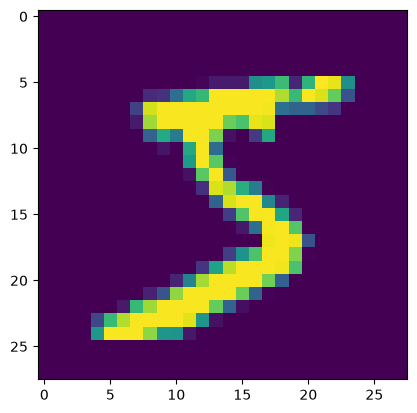

In [36]:
plt.imshow(sample.to_numpy().reshape((28, 28)))

<h4>Look at the different values our sample image contains. Necessary to see how to preprocess our data</h4>

In [32]:
values, counts = np.unique(sample, return_counts=True)

swapped = False
while True:
    swapped = False
    for i in range(len(counts) - 1):
        if counts[i] < counts[i + 1]:
            temp = counts[i]
            counts[i] = counts[i + 1]
            counts[i + 1] = temp
            swapped = True

    if not swapped:
        break

values, counts

(array([  0,   1,   2,   3,   9,  11,  14,  16,  18,  23,  24,  25,  26,
         27,  30,  35,  36,  39,  43,  45,  46,  49,  55,  56,  64,  66,
         70,  78,  80,  81,  82,  90,  93,  94, 107, 108, 114, 119, 126,
        127, 130, 132, 133, 135, 136, 139, 148, 150, 154, 156, 160, 166,
        170, 171, 172, 175, 182, 183, 186, 187, 190, 195, 198, 201, 205,
        207, 212, 213, 219, 221, 225, 226, 229, 238, 240, 241, 242, 244,
        247, 249, 250, 251, 252, 253, 255]),
 array([618,  54,   5,   3,   3,   3,   2,   2,   2,   2,   2,   2,   2,
          2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1]))

<h4>Component to remove transparent pixels from our digits of the images</h4>

In [5]:
class ShadeRemover(BaseEstimator, TransformerMixin):
    """_summary_

    Args:
        threshold (_float_): Determine at what value the shade should be removed. All values below this threshold will be set to 0 (white), and all values above will be set to 1 (black).
    """
    def __init__(self, threshold=0.3):
        self.threshold = threshold

    def fit(self, X, y=None):
        return self

    def transform(self, X: np.ndarray, y=None):
        X_new = (X >= self.threshold).astype(np.int8)
        return X_new

<h4>Prepare the preprocessing pipeline</h4>

In [6]:
preprocess_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('shade_remover', ShadeRemover())
])

X_train_prep = preprocess_pipeline.fit_transform(X_train)

<h4>Looking at the different values of our sample image after preprocessing</h4>

In [33]:
np.unique(X_train_prep)

array([0, 1], dtype=int8)

<h4>Create our classification model and train it</h4>

In [7]:
classifier = KNeighborsClassifier(n_neighbors=4, weights='distance')
classifier.fit(X_train_prep, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](10,)","['0','1','2',...,'7','8','9']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


<h4>Get a cross validation score with f1 weighted</h4>

In [8]:
X_test_prep = preprocess_pipeline.fit_transform(X_test)
cross_val_score(classifier, X_test_prep, y_test, cv=5, scoring='f1_weighted')

array([0.9247904 , 0.91994121, 0.94193694, 0.96232955, 0.96689433])

<h4>Look at the different metrics of our model. So far, so good</h4>

In [27]:
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import cross_val_predict

y_test_pred = classifier.predict(X_test_prep)
y_test_proba = classifier.predict_proba(X_test_prep)

print(f"Precision: {precision_score(y_test, y_test_pred, average='weighted')}")
print(f"Recall: {recall_score(y_test, y_test_pred, average='weighted')}")
print(f"F1 Score: {f1_score(y_test, y_test_pred, average='weighted')}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_test_proba, average="weighted", multi_class='ovr')}")

Precision: 0.9660268908191254
Recall: 0.9657
F1 Score: 0.9656528788204787
ROC AUC Score: 0.993138300536584


<h4>Look at the confusion matrix to visualise the misclassifications</h4>

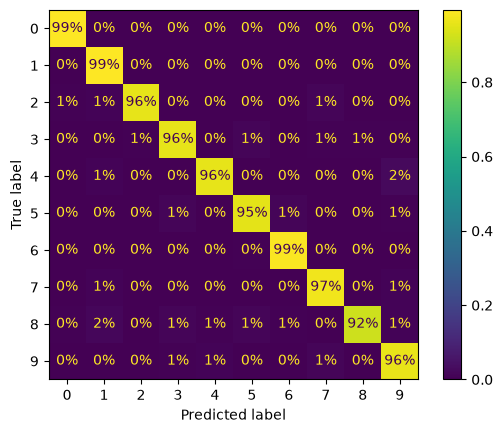

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
y_train_pred = cross_val_predict(classifier, X_train_prep, y_train, cv=3)

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true", values_format=".0%")

<h4>Save the model</h4>

In [12]:
import joblib
joblib.dump(classifier, '../models/knn_classifier.joblib')

['../models/knn_classifier.joblib']